# WK5 — Backbone × Classifier Shortlisting (two-stage)

Course: AIT-506 Machine Learning | Project: Exam Cheating Detection (5 classes)

This extends the shortlisting to compare four pretrained backbones as feature
extractors, not just one. For each backbone we extract a feature vector per image,
then run the same two-stage panel (normal vs cheating, then subtype) with seven
classifiers. The result is a backbone-by-classifier grid of macro F1, so we can
see which feature source and which classifier combine best.

```
Stage 1 — Binary    normal act  vs  cheating
       │ if cheating
       ▼
Stage 2 — Subtype   direct cheating / giving code / giving object / looking friend
```

Backbones compared (all frozen, ImageNet-pretrained, used only as feature
extractors): ResNet-18, MobileNet-V3-Small, EfficientNet-B0, and YOLOv8-cls.

Same clean foundation as before: duplicates removed by hash, stratified split,
features standardised on train only. Primary metric: macro F1.

Note on runtime: extracting features with four backbones is the slow part. Use a
GPU runtime (Runtime > Change runtime type > GPU); on CPU this can take several
minutes per backbone.

## 0  Mount Drive and install ultralytics (for YOLO features)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

try:
    import ultralytics  # noqa
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q'])
print('ultralytics ready')

Mounted at /content/drive
ultralytics ready


## 1  Imports and configuration

In [ ]:
import hashlib, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CANDIDATES = [
    Path('/content/drive/MyDrive/ExamCheatingDataset_preprocessed'),
    Path('/content/drive/MyDrive/ExamCheatingDataset'),
]
DATA_ROOT = next((p for p in CANDIDATES if p.exists()), None)
assert DATA_ROOT is not None, 'No dataset folder found — edit CANDIDATES.'
TRAIN_DIR  = DATA_ROOT / 'train'
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.gif'}
CLASSES    = sorted(d.name for d in TRAIN_DIR.iterdir() if d.is_dir())
NORMAL_CLS = 'normal act'
assert NORMAL_CLS in CLASSES, f'{NORMAL_CLS!r} not in {CLASSES}'
SUB_CLASSES = [c for c in CLASSES if c != NORMAL_CLS]
VAL_SPLIT, IMG_SIZE, BATCH = 0.20, 224, 64
print('Device :', DEVICE, '| Classes:', CLASSES)

Device : cpu | Classes: ['direct cheating', 'giving code', 'giving object', 'looking friend', 'normal act']


## 2  Clean manifest, stratified split

In [ ]:
def list_images(folder):
    return [p for p in folder.rglob('*') if p.suffix.lower() in IMG_EXTS and p.is_file()]

seen, paths, labels, dropped = set(), [], [], 0
for c in CLASSES:
    for p in list_images(TRAIN_DIR / c):
        try:
            h = hashlib.md5(p.read_bytes()).hexdigest()
        except Exception:
            continue
        if h in seen:
            dropped += 1; continue
        seen.add(h); paths.append(str(p)); labels.append(CLASSES.index(c))

paths, labels = np.array(paths), np.array(labels)
tr_paths, va_paths, y_train, y_val = train_test_split(
    paths, labels, test_size=VAL_SPLIT, stratify=labels, random_state=SEED)
print(f'Kept {len(paths)} images ({dropped} duplicates removed) | train {len(tr_paths)} | val {len(va_paths)}')

Kept 1551 images (11 duplicates removed) | train 1240 | val 311


## 3  Backbone feature extractors

Each backbone has its classification head removed and weights frozen, so it acts
as a feature extractor. ResNet-18 gives 512 features, MobileNet-V3 gives 576,
EfficientNet-B0 gives 1280. YOLOv8-cls uses the ultralytics `embed` API. Every
extractor takes a list of image paths and returns a feature matrix.

In [ ]:
IMAGENET_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def _torchvision_extractor(model):
    model = model.to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    @torch.no_grad()
    def extract(path_list):
        feats = []
        for i in range(0, len(path_list), BATCH):
            imgs = torch.stack([IMAGENET_TF(Image.open(p).convert('RGB'))
                                for p in path_list[i:i+BATCH]]).to(DEVICE)
            feats.append(model(imgs).cpu().numpy())
        return np.vstack(feats)
    return extract

def build_resnet():
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT); m.fc = nn.Identity()
    return _torchvision_extractor(m)

def build_mobilenet():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    m.classifier = nn.Identity(); return _torchvision_extractor(m)

def build_efficientnet():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    m.classifier = nn.Identity(); return _torchvision_extractor(m)

def build_yolo():
    from ultralytics import YOLO
    m = YOLO('yolov8n-cls.pt')
    def extract(path_list):
        feats = []
        for i in range(0, len(path_list), BATCH):
            embs = m.embed(list(path_list[i:i+BATCH]), verbose=False)
            feats.extend([e.detach().cpu().numpy().ravel() for e in embs])
        return np.vstack(feats)
    return extract

BACKBONE_BUILDERS = {
    'ResNet-18':       build_resnet,
    'MobileNet-V3':    build_mobilenet,
    'EfficientNet-B0': build_efficientnet,
    'YOLOv8-cls':      build_yolo,
}
print('Backbone builders ready:', list(BACKBONE_BUILDERS))

Backbone builders ready: ['ResNet-18', 'MobileNet-V3', 'EfficientNet-B0', 'YOLOv8-cls']


## 4  Two-stage panel (runs on any feature matrix)

Given train and validation features, this builds Stage 1 (normal vs cheating) and
Stage 2 (subtype) for each classifier family and returns end-to-end metrics.

In [ ]:
normal_idx      = CLASSES.index(NORMAL_CLS)
sub_classes_idx = [CLASSES.index(c) for c in SUB_CLASSES]
sub_pos         = {CLASSES.index(c): i for i, c in enumerate(SUB_CLASSES)}

yb_train   = (y_train != normal_idx).astype(int)
cheat_mask = (y_train != normal_idx)
ysub_train = np.array([sub_pos[l] for l in y_train[cheat_mask]])

MODEL_FACTORIES = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, class_weight='balanced'),
    'k-NN':                lambda: KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':           lambda: SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'),
    'Decision Tree':       lambda: DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    'Random Forest':       lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                          random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   lambda: HistGradientBoostingClassifier(random_state=SEED),
    'Neural Net (MLP)':    lambda: MLPClassifier(hidden_layer_sizes=(256, 128),
                                                 max_iter=500, random_state=SEED),
}

def _fit(name, X, y):
    clf = MODEL_FACTORIES[name]()
    if name == 'Gradient Boosting':
        clf.fit(X, y, sample_weight=compute_sample_weight('balanced', y))
    else:
        clf.fit(X, y)
    return clf

def two_stage_panel(X_train, X_val):
    Xsub_train = X_train[cheat_mask]
    out = {}
    for name in MODEL_FACTORIES:
        s1 = _fit(name, X_train, yb_train)
        s2 = _fit(name, Xsub_train, ysub_train)
        s1_pred = s1.predict(X_val)
        pred = np.full(len(X_val), normal_idx, dtype=int)
        cheat = (s1_pred == 1)
        if cheat.any():
            pred[np.where(cheat)[0]] = [sub_classes_idx[i] for i in s2.predict(X_val[cheat])]
        acc = accuracy_score(y_val, pred)
        f1  = f1_score(y_val, pred, average='macro', zero_division=0)
        out[name] = {'f1': f1, 'acc': acc, 'pred': pred}
    return out

print('Panel ready.')

Panel ready.


## 5  Run every backbone

For each backbone: build it, extract train and val features, standardise on train,
then run the full two-stage panel. YOLO is wrapped so a failure there still leaves
the three CNN backbones intact.

In [ ]:
ALL = {}   # ALL[backbone][classifier] = {f1, acc, pred}
for bb, builder in BACKBONE_BUILDERS.items():
    print(f'\n=== {bb} ===')
    try:
        t0 = time.time()
        extract = builder()
        Xtr = extract(tr_paths)
        Xva = extract(va_paths)
        sc = StandardScaler().fit(Xtr)
        Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
        print(f'  features {Xtr.shape[1]}-dim  ({time.time()-t0:.0f}s)')
        ALL[bb] = two_stage_panel(Xtr, Xva)
        best = max(ALL[bb], key=lambda k: ALL[bb][k]['f1'])
        print(f'  best here: {best} (macro F1 {ALL[bb][best]["f1"]:.3f})')
    except Exception as e:
        print(f'  SKIPPED {bb}: {e}')

print('\nBackbones evaluated:', list(ALL))


=== ResNet-18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 96.6MB/s]


  features 512-dim  (224s)
  best here: Logistic Regression (macro F1 0.940)

=== MobileNet-V3 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 31.3MB/s]


  features 576-dim  (33s)
  best here: Gradient Boosting (macro F1 0.814)

=== EfficientNet-B0 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 61.1MB/s]


  features 1280-dim  (159s)
  best here: Neural Net (MLP) (macro F1 0.924)

=== YOLOv8-cls ===
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  features 256-dim  (35s)
  best here: Neural Net (MLP) (macro F1 0.844)

Backbones evaluated: ['ResNet-18', 'MobileNet-V3', 'EfficientNet-B0', 'YOLOv8-cls']


## 6  Backbone × classifier grid (two-stage macro F1)

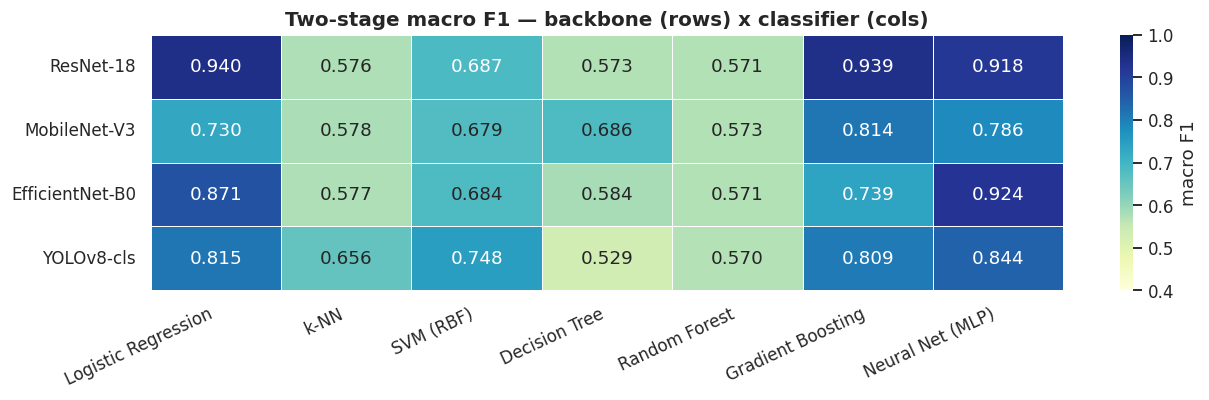

                 Logistic Regression   k-NN  SVM (RBF)  Decision Tree  Random Forest  Gradient Boosting  Neural Net (MLP)
ResNet-18                      0.940  0.576      0.687          0.573          0.571              0.939             0.918
MobileNet-V3                   0.730  0.578      0.679          0.686          0.573              0.814             0.786
EfficientNet-B0                0.871  0.577      0.684          0.584          0.571              0.739             0.924
YOLOv8-cls                     0.815  0.656      0.748          0.529          0.570              0.809             0.844


In [ ]:
grid = pd.DataFrame({bb: {clf: ALL[bb][clf]['f1'] for clf in MODEL_FACTORIES}
                     for bb in ALL}).T          # rows = backbones, cols = classifiers
grid = grid[list(MODEL_FACTORIES)]

plt.figure(figsize=(12, 1 + 0.7 * len(grid)))
sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.4, vmax=1.0,
            cbar_kws={'label': 'macro F1'}, linewidths=0.5)
plt.title('Two-stage macro F1 — backbone (rows) x classifier (cols)', fontweight='bold')
plt.xticks(rotation=25, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig('wk5_backbone_classifier_grid.png', bbox_inches='tight'); plt.show()

print(grid.round(3).to_string())

## 7  All combinations ranked

In [ ]:
combos = [{'Backbone': bb, 'Classifier': clf,
           'Macro F1': ALL[bb][clf]['f1'], 'Accuracy': ALL[bb][clf]['acc']}
          for bb in ALL for clf in MODEL_FACTORIES]
combo_df = (pd.DataFrame(combos).sort_values('Macro F1', ascending=False)
            .reset_index(drop=True))
combo_df.index += 1
print('=' * 60)
print('  ALL BACKBONE + CLASSIFIER COMBINATIONS (two-stage)')
print('=' * 60)
print(combo_df.round(4).head(15).to_string())
print('=' * 60)

best = combo_df.iloc[0]
print(f"Best combination: {best['Backbone']} + {best['Classifier']} "
      f"-> macro F1 {best['Macro F1']:.3f}, accuracy {best['Accuracy']:.3f}")

  ALL BACKBONE + CLASSIFIER COMBINATIONS (two-stage)
           Backbone           Classifier  Macro F1  Accuracy
1         ResNet-18  Logistic Regression    0.9401    0.9646
2         ResNet-18    Gradient Boosting    0.9386    0.9614
3   EfficientNet-B0     Neural Net (MLP)    0.9235    0.9807
4         ResNet-18     Neural Net (MLP)    0.9182    0.9743
5   EfficientNet-B0  Logistic Regression    0.8709    0.9743
6        YOLOv8-cls     Neural Net (MLP)    0.8444    0.9678
7        YOLOv8-cls  Logistic Regression    0.8153    0.9614
8      MobileNet-V3    Gradient Boosting    0.8135    0.9582
9        YOLOv8-cls    Gradient Boosting    0.8091    0.9550
10     MobileNet-V3     Neural Net (MLP)    0.7860    0.9711
11       YOLOv8-cls            SVM (RBF)    0.7476    0.9743
12  EfficientNet-B0    Gradient Boosting    0.7387    0.9582
13     MobileNet-V3  Logistic Regression    0.7302    0.9582
14        ResNet-18            SVM (RBF)    0.6868    0.9711
15     MobileNet-V3        Decis

## 8  Best classifier per backbone

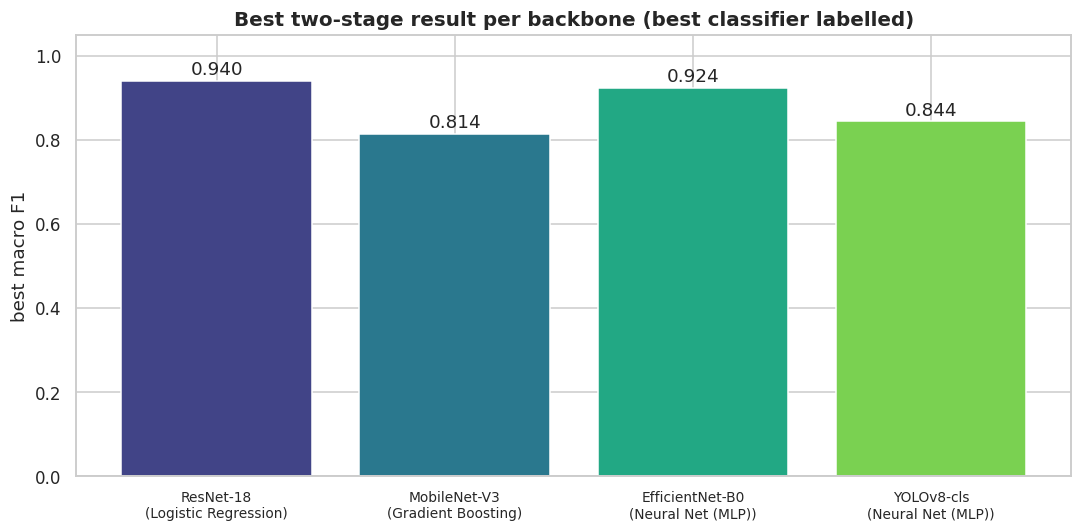

In [ ]:
best_per_bb = {bb: max(ALL[bb], key=lambda k: ALL[bb][k]['f1']) for bb in ALL}
names = list(best_per_bb)
f1s   = [ALL[bb][best_per_bb[bb]]['f1'] for bb in names]
labels = [f'{bb}\n({best_per_bb[bb]})' for bb in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, f1s, color=sns.color_palette('viridis', len(names)))
for bar, v, lab in zip(bars, f1s, labels):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', va='bottom')
plt.xticks(range(len(names)), labels, fontsize=9)
plt.ylim(0, 1.05); plt.ylabel('best macro F1')
plt.title('Best two-stage result per backbone (best classifier labelled)', fontweight='bold')
plt.tight_layout(); plt.savefig('wk5_best_per_backbone.png', bbox_inches='tight'); plt.show()

## 9  Confusion matrices for the top three combinations

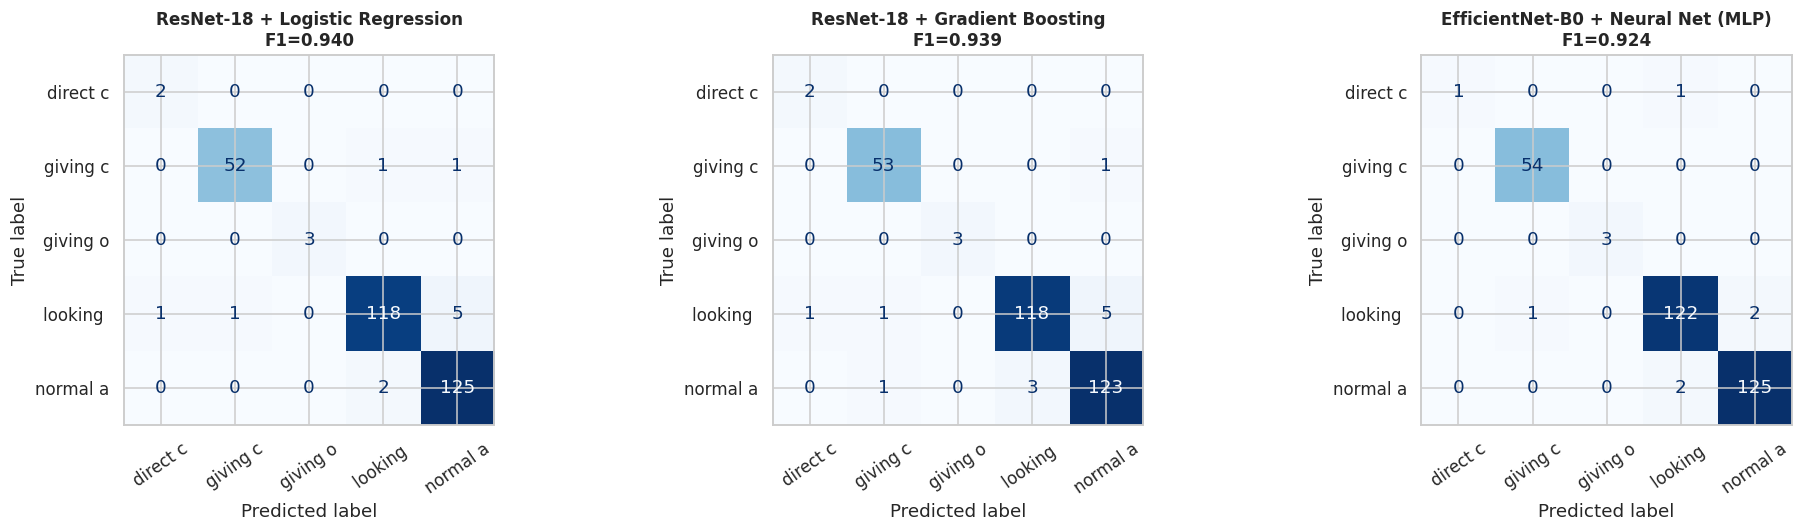

In [ ]:
top3 = combo_df.head(3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_, row) in zip(axes, top3.iterrows()):
    pred = ALL[row['Backbone']][row['Classifier']]['pred']
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=[c[:8] for c in CLASSES]).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{row['Backbone']} + {row['Classifier']}\nF1={row['Macro F1']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.savefig('wk5_top3_confusion.png', bbox_inches='tight'); plt.show()

## 10  Shortlist and next steps

In [ ]:
print('Shortlist — top 3 backbone + classifier combinations (two-stage):')
for i, (_, row) in enumerate(combo_df.head(3).iterrows(), 1):
    print(f"  {i}. {row['Backbone']} + {row['Classifier']:20} "
          f"macro F1 {row['Macro F1']:.3f} | acc {row['Accuracy']:.3f}")

print('\nReading the grid:')
print('- Rows are feature sources (backbones), columns are classifiers.')
print('- A strong row means that backbone produces features that separate the')
print('  cheating subtypes well; a strong column means that classifier uses the')
print('  features well. The best cell is the combination to carry forward.')
print('- Macro F1 is primary because of the ~53x imbalance; the two smallest')
print('  classes have very few validation images, so their scores are noisy.')
print('\nWK6 Finalizing: take the top one or two combinations and tune them with')
print('GridSearchCV (focus on the Stage 2 classifier), optionally apply SMOTE to the')
print('Stage 2 training features only, and compare against the end-to-end fine-tuned')
print('CNNs from the deep-learning notebook.')

Shortlist — top 3 backbone + classifier combinations (two-stage):
  1. ResNet-18 + Logistic Regression  macro F1 0.940 | acc 0.965
  2. ResNet-18 + Gradient Boosting    macro F1 0.939 | acc 0.961
  3. EfficientNet-B0 + Neural Net (MLP)     macro F1 0.924 | acc 0.981

Reading the grid:
- Rows are feature sources (backbones), columns are classifiers.
- A strong row means that backbone produces features that separate the
  cheating subtypes well; a strong column means that classifier uses the
  features well. The best cell is the combination to carry forward.
- Macro F1 is primary because of the ~53x imbalance; the two smallest
  classes have very few validation images, so their scores are noisy.

WK6 Finalizing: take the top one or two combinations and tune them with
GridSearchCV (focus on the Stage 2 classifier), optionally apply SMOTE to the
Stage 2 training features only, and compare against the end-to-end fine-tuned
CNNs from the deep-learning notebook.
